In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ehababoelnaga/anemia-types-classification/diagnosed_cbc_data_v4.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/ehababoelnaga/anemia-types-classification/diagnosed_cbc_data_v4.csv')

print("=" * 60)
print("DATASET SHAPE:", df.shape)
print("=" * 60)

print("\nCOLUMNS & DTYPES:")
print(df.dtypes)

print("\nFIRST 5 ROWS:")
print(df.head())

print("\nBASIC STATS:")
print(df.describe())

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nTARGET COLUMN NAME:", df.columns[-1])
print("\nCLASS DISTRIBUTION:")
print(df.iloc[:, -1].value_counts())

print("\nUNIQUE CLASSES:", df.iloc[:, -1].nunique())
print(df.iloc[:, -1].unique())

DATASET SHAPE: (1281, 15)

COLUMNS & DTYPES:
WBC          float64
LYMp         float64
NEUTp        float64
LYMn         float64
NEUTn        float64
RBC          float64
HGB          float64
HCT          float64
MCV          float64
MCH          float64
MCHC         float64
PLT          float64
PDW          float64
PCT          float64
Diagnosis     object
dtype: object

FIRST 5 ROWS:
    WBC  LYMp  NEUTp  LYMn  NEUTn   RBC  HGB    HCT   MCV   MCH  MCHC    PLT  \
0  10.0  43.2   50.1   4.3    5.0  2.77  7.3   24.2  87.7  26.3  30.1  189.0   
1  10.0  42.4   52.3   4.2    5.3  2.84  7.3   25.0  88.2  25.7  20.2  180.0   
2   7.2  30.7   60.7   2.2    4.4  3.97  9.0   30.5  77.0  22.6  29.5  148.0   
3   6.0  30.2   63.5   1.8    3.8  4.22  3.8   32.8  77.9  23.2  29.8  143.0   
4   4.2  39.1   53.7   1.6    2.3  3.93  0.4  316.0  80.6  23.9  29.7  236.0   

    PDW   PCT                      Diagnosis  
0  12.5  0.17  Normocytic hypochromic anemia  
1  12.5  0.16  Normocytic hypochromi

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/ehababoelnaga/anemia-types-classification/diagnosed_cbc_data_v4.csv')

# ── Outlier capping (IQR × 3 per column) ─────────────────────────────────────
features = [c for c in df.columns if c != 'Diagnosis']
df_clean = df.copy()
for col in features:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
    df_clean[col] = df_clean[col].clip(lower, upper)

print("After outlier capping:")
print(df_clean[features].describe().loc[['min','max']].T)

# ── Encode target ─────────────────────────────────────────────────────────────
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['Diagnosis'])
print("\nClass mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

# ── Features / target ────────────────────────────────────────────────────────
X = df_clean[features].values
y = df_clean['label'].values

# ── SMOTE for class imbalance ─────────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"\nAfter SMOTE — X: {X_res.shape}, class counts: {dict(zip(*np.unique(y_res, return_counts=True)))}")

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler = RobustScaler()
X_res = scaler.fit_transform(X_res)

# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# ── Models ───────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                             min_samples_split=2, random_state=42, n_jobs=-1)

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     use_label_encoder=False, eval_metric='mlogloss',
                     random_state=42, n_jobs=-1)

gb = GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                 learning_rate=0.05, random_state=42)

# Voting ensemble (soft)
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)],
    voting='soft', n_jobs=-1)

# ── CV score before final fit ─────────────────────────────────────────────────
print("\n── 5-Fold CV Accuracy (on resampled train) ──")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in [('RandomForest', rf), ('XGBoost', xgb),
                     ('GradientBoosting', gb), ('Ensemble', ensemble)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring='accuracy', n_jobs=-1)
    print(f"  {name:20s}: {scores.mean():.4f} ± {scores.std():.4f}")

# ── Final fit on full train set ───────────────────────────────────────────────
print("\nFitting final ensemble...")
ensemble.fit(X_train, y_train)
print("Done.")

After outlier capping:
            min        max
WBC     0.80000   16.72000
LYMp   25.84500   25.84500
NEUTp  51.86700   96.74400
LYMn    1.88076    1.88076
NEUTn   4.97718    5.26376
RBC     1.46000    7.83000
HGB     2.70000   21.60000
HCT    18.34220   67.01040
MCV    54.20000  117.20000
MCH    13.20000   41.90000
MCHC   23.70000   39.80000
PLT    10.00000  660.00000
PDW     9.10000   18.90000
PCT     0.01000    0.53112

Class mapping:
  0: Healthy
  1: Iron deficiency anemia
  2: Leukemia
  3: Leukemia with thrombocytopenia
  4: Macrocytic anemia
  5: Normocytic hypochromic anemia
  6: Normocytic normochromic anemia
  7: Other microcytic anemia
  8: Thrombocytopenia

After SMOTE — X: (3024, 14), class counts: {np.int64(0): np.int64(336), np.int64(1): np.int64(336), np.int64(2): np.int64(336), np.int64(3): np.int64(336), np.int64(4): np.int64(336), np.int64(5): np.int64(336), np.int64(6): np.int64(336), np.int64(7): np.int64(336), np.int64(8): np.int64(336)}

Train: (2419, 14) | Te

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:02:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  XGBoost             : 0.9934 ± 0.0015
  GradientBoosting    : 0.9921 ± 0.0030


[13:03:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:03:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:03:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:03:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[13:03:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



  Ensemble            : 0.9955 ± 0.0024

Fitting final ensemble...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:03:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done.


  FINAL TEST ACCURACY : 99.83%

── Classification Report ──────────────────────────────────────
                                precision    recall  f1-score   support

                       Healthy     0.9853    1.0000    0.9926        67
        Iron deficiency anemia     1.0000    1.0000    1.0000        67
                      Leukemia     1.0000    1.0000    1.0000        67
Leukemia with thrombocytopenia     1.0000    1.0000    1.0000        68
             Macrocytic anemia     1.0000    1.0000    1.0000        67
 Normocytic hypochromic anemia     1.0000    0.9851    0.9925        67
Normocytic normochromic anemia     1.0000    1.0000    1.0000        68
       Other microcytic anemia     1.0000    1.0000    1.0000        67
              Thrombocytopenia     1.0000    1.0000    1.0000        67

                      accuracy                         0.9983       605
                     macro avg     0.9984    0.9983    0.9983       605
                  weighted avg     0.9

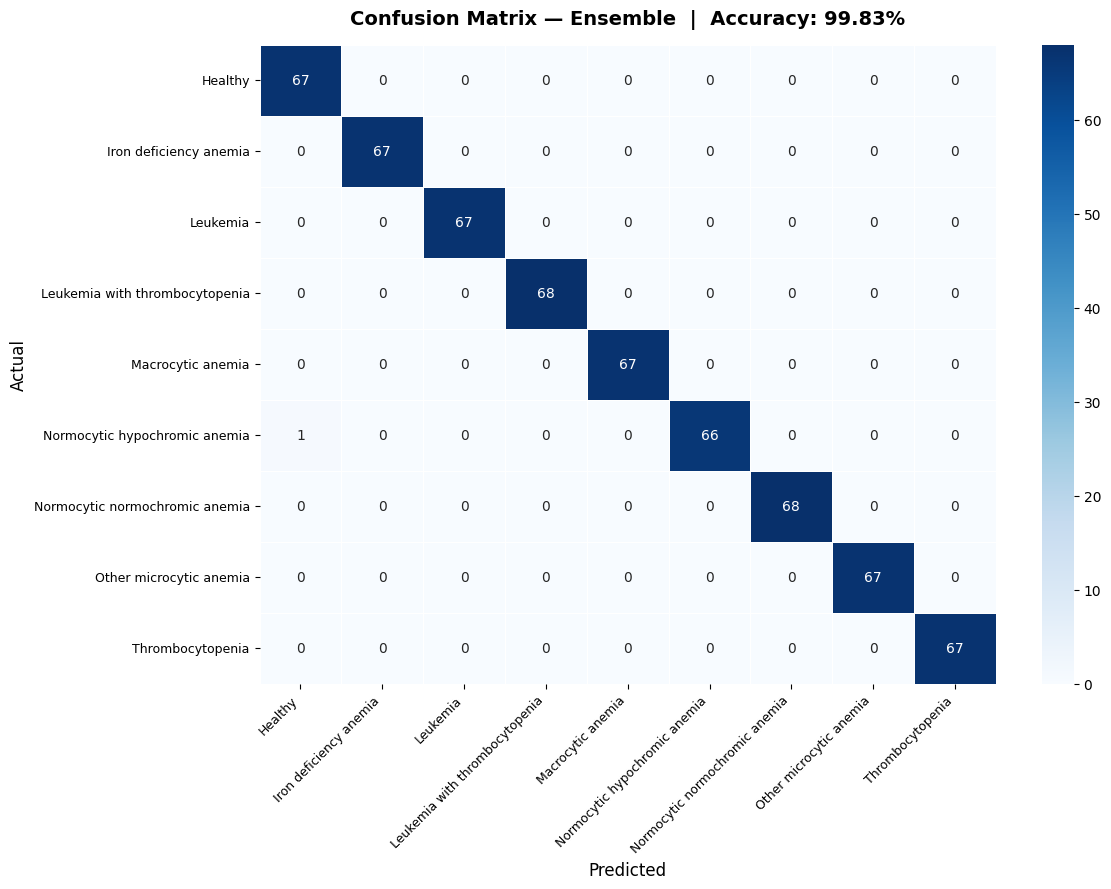

Saved → confusion_matrix.png


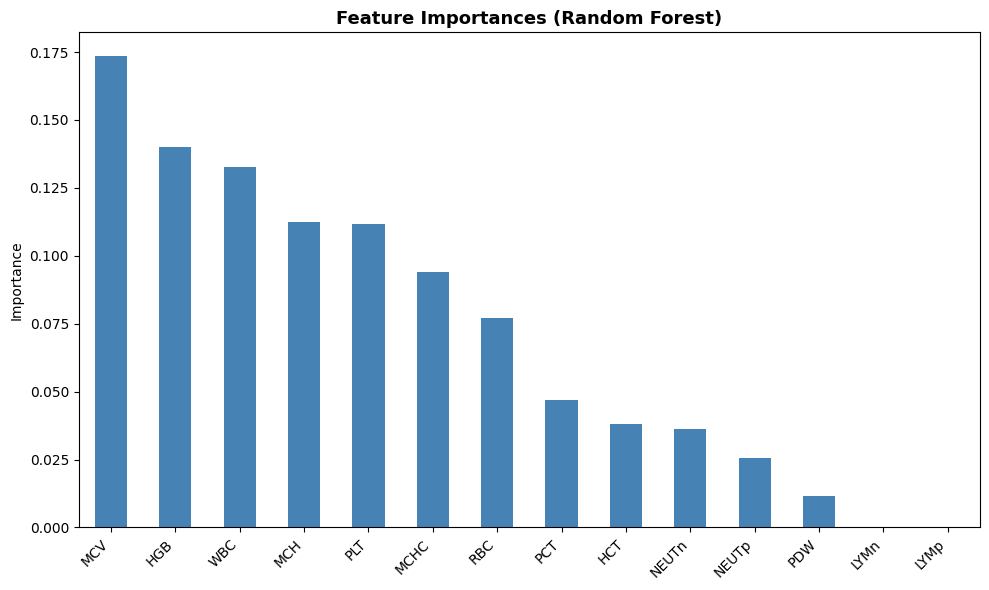

Saved → feature_importance.png


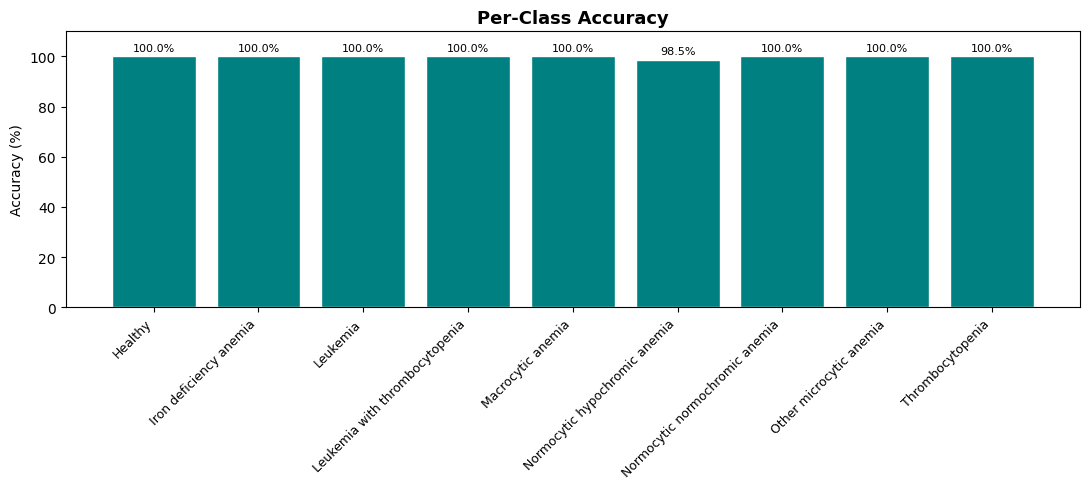

Saved → per_class_accuracy.png

── Saved Artifacts ──────────────────────────────────────────
  ✓ blood_disease_model.pkl             16622.5 KB
  ✓ label_encoder.pkl                       0.4 KB
  ✓ scaler.pkl                              0.6 KB
  ✓ confusion_matrix.png                  155.2 KB
  ✓ feature_importance.png                 51.2 KB
  ✓ per_class_accuracy.png                 92.6 KB

── Quick sanity check (5 test samples) ──────────────────────
  ✓ True: Iron deficiency anemia                   | Pred: Iron deficiency anemia
  ✓ True: Normocytic normochromic anemia           | Pred: Normocytic normochromic anemia
  ✓ True: Thrombocytopenia                         | Pred: Thrombocytopenia
  ✓ True: Normocytic hypochromic anemia            | Pred: Normocytic hypochromic anemia
  ✓ True: Leukemia                                 | Pred: Leukemia


In [6]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred = ensemble.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print("=" * 65)
print(f"  FINAL TEST ACCURACY : {acc * 100:.2f}%")
print("=" * 65)

print("\n── Classification Report ──────────────────────────────────────")
report = classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                digits=4)
print(report)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
ax.set_title(f'Confusion Matrix — Ensemble  |  Accuracy: {acc*100:.2f}%',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
print("Saved → confusion_matrix.png")

# ── Feature Importance (from RF inside ensemble) ──────────────────────────────
rf_fitted = ensemble.estimators_[0]
importances = pd.Series(rf_fitted.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

fig2, ax2 = plt.subplots(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', ax=ax2)
ax2.set_title('Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=150)
plt.show()
print("Saved → feature_importance.png")

# ── Per-class accuracy bar ────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig3, ax3 = plt.subplots(figsize=(11, 5))
bars = ax3.bar(le.classes_, per_class_acc * 100, color='teal', edgecolor='white')
ax3.set_ylim(0, 110)
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
for bar, val in zip(bars, per_class_acc):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5, f'{val*100:.1f}%',
             ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_accuracy.png', dpi=150)
plt.show()
print("Saved → per_class_accuracy.png")

# ── Save model artifacts ──────────────────────────────────────────────────────
with open('/kaggle/working/blood_disease_model.pkl', 'wb') as f:
    pickle.dump(ensemble, f)

with open('/kaggle/working/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('/kaggle/working/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n── Saved Artifacts ──────────────────────────────────────────")
for fname in ['blood_disease_model.pkl', 'label_encoder.pkl',
              'scaler.pkl', 'confusion_matrix.png',
              'feature_importance.png', 'per_class_accuracy.png']:
    path = f'/kaggle/working/{fname}'
    size = os.path.getsize(path) / 1024
    print(f"  ✓ {fname:35s} {size:7.1f} KB")

print("\n── Quick sanity check (5 test samples) ──────────────────────")
sample_idx = np.random.choice(len(X_test), 5, replace=False)
for i in sample_idx:
    true  = le.inverse_transform([y_test[i]])[0]
    pred  = le.inverse_transform([y_pred[i]])[0]
    match = "✓" if true == pred else "✗"
    print(f"  {match} True: {true:40s} | Pred: {pred}")